In [1]:
import sys

sys.path.insert(0, "..")

import librosa
from pathlib import Path
from IPython.display import Audio

import pygaborstm as stm

config = stm.Config(use_gpu=False, resolution="medium")
model = stm.PyGaborSTM(config)

print(f"PyGaborSTM version: {stm.__version__}")

PyGaborSTM version: 0.1.0


In [2]:
# %% Load audio file
filepath = Path("notebooks/assets/hello_world.wav")

audio, sr = librosa.load(filepath, sr=16000)

print(f"Loaded: {filepath.name}")
print(f"Audio shape: {audio.shape}, SR: {sr}")
print(f"Duration: {len(audio) / sr:.2f}s")

Audio(audio, rate=sr)

Loaded: hello_world.wav
Audio shape: (18391,), SR: 16000
Duration: 1.15s


In [3]:
# Compute auditory spectrogram
spectrogram = model.spectrogram(audio)

print("\n=== Spectrogram Stats ===")
print(f"Shape: {spectrogram.shape}")
print(f"Min: {spectrogram.data.min():.6f}")
print(f"Max: {spectrogram.data.max():.6f}")
print(f"Mean: {spectrogram.data.mean():.6f}")
print(f"Std: {spectrogram.data.std():.6f}")
print(f"Time range: {spectrogram.times[0]:.3f}s - {spectrogram.times[-1]:.3f}s")
print(f"Freq range: {spectrogram.freqs[0]:.1f}Hz - {spectrogram.freqs[-1]:.1f}Hz")

print("\nFirst 5x5 corner:")
print(spectrogram.data[:5, :5])


=== Spectrogram Stats ===
Shape: (256, 144)
Min: 0.000000
Max: 0.269632
Mean: 0.058239
Std: 0.043825
Time range: 0.000s - 1.144s
Freq range: 180.0Hz - 7091.4Hz

First 5x5 corner:
[[0.0035496  0.0040066  0.00481256 0.00463916 0.0021094 ]
 [0.00356361 0.00381832 0.00523448 0.00440154 0.00215309]
 [0.00355505 0.00360171 0.00545469 0.00402282 0.00242928]
 [0.0035213  0.00335337 0.0054629  0.00348687 0.00203908]
 [0.00346422 0.00312178 0.00531211 0.00314634 0.00265208]]


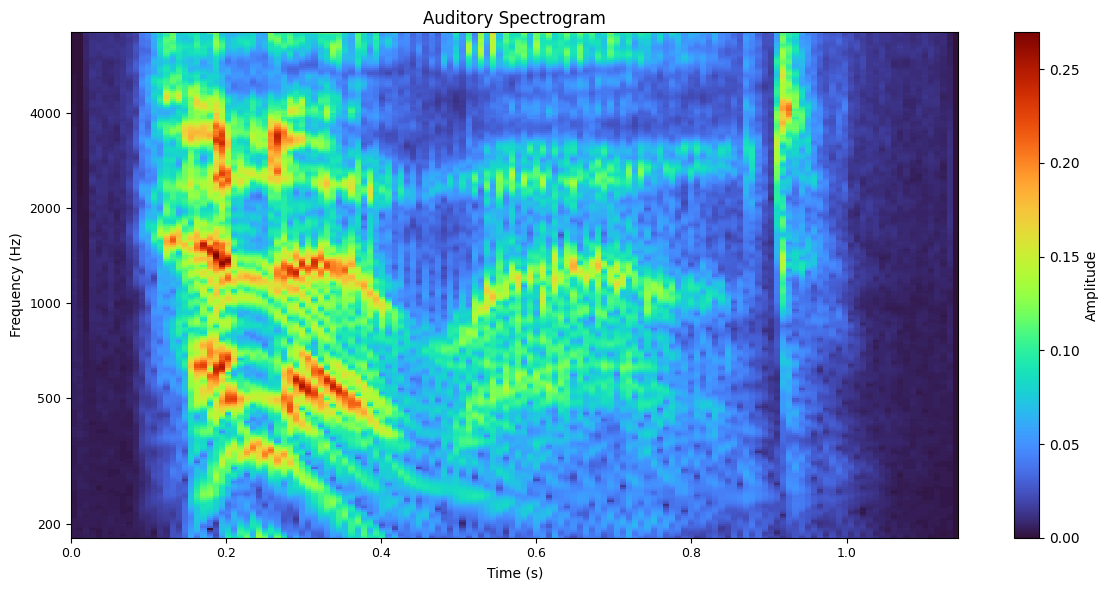

<Axes: title={'center': 'Auditory Spectrogram'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>

In [4]:
# Plot spectrogram
stm.plot.plt_spectrogram(spectrogram, title="Auditory Spectrogram")

In [5]:
# Compute RSF representation
rsf = model.rsf(spectrogram)

print("\n=== RSF Stats ===")
print(f"Shape: {rsf.shape}")
print(f"  - n_frames: {rsf.n_frames}")
print(f"  - n_rates: {rsf.n_rates}")
print(f"  - n_scales: {rsf.n_scales}")
print(f"  - n_freqs: {rsf.n_freqs}")
print(f"Min: {rsf.data.min():.6f}")
print(f"Max: {rsf.data.max():.6f}")
print(f"Rates: {rsf.rates}")
print(f"Scales: {rsf.scales}")


=== RSF Stats ===
Shape: (83, 20, 12, 256)
  - n_frames: 83
  - n_rates: 20
  - n_scales: 12
  - n_freqs: 256
Min: 0.089758
Max: 40.583298
Rates: [-32.         -23.51575188 -17.28095582 -12.69920842  -9.33223232
  -6.85795186  -5.0396842   -3.70349885  -2.72158     -2.
   2.           2.72158      3.70349885   5.0396842    6.85795186
   9.33223232  12.69920842  17.28095582  23.51575188  32.        ]
Scales: [0.25       0.34258775 0.46946546 0.64333245 0.88159125 1.20808944
 1.65550656 2.26862504 3.10881256 4.26016436 5.83792042 8.        ]


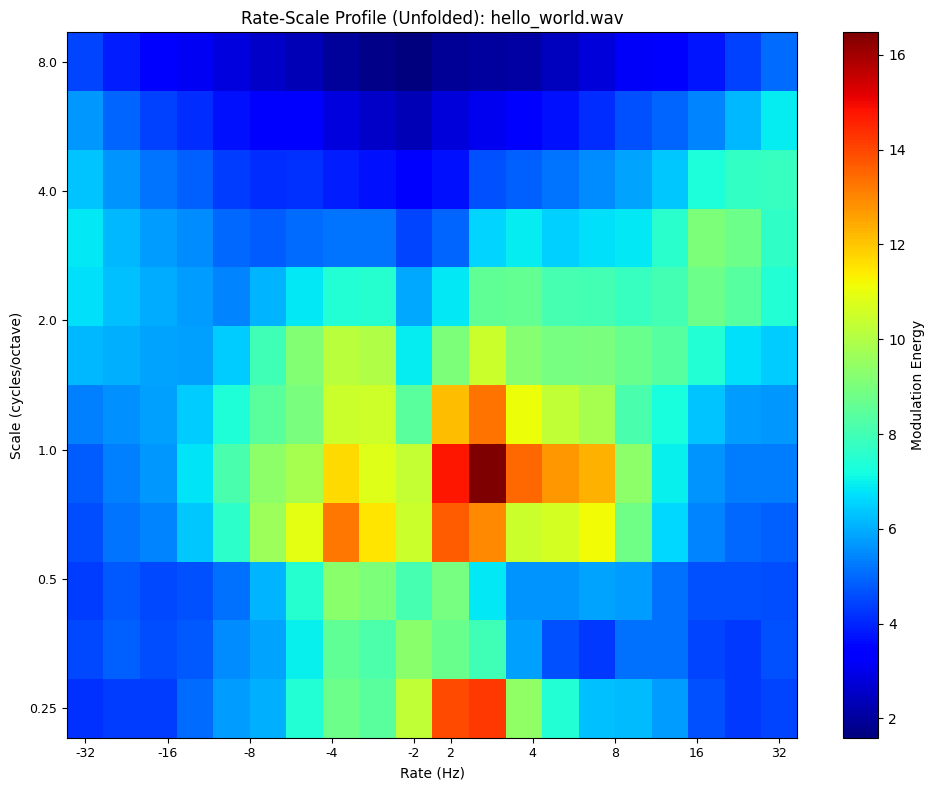

<Axes: title={'center': 'Rate-Scale Profile (Unfolded): hello_world.wav'}, xlabel='Rate (Hz)', ylabel='Scale (cycles/octave)'>

In [6]:
# Plot RSF - unfolded
stm.plot.plt_rsf(rsf, title=f"Rate-Scale Profile (Unfolded): {filepath.name}")

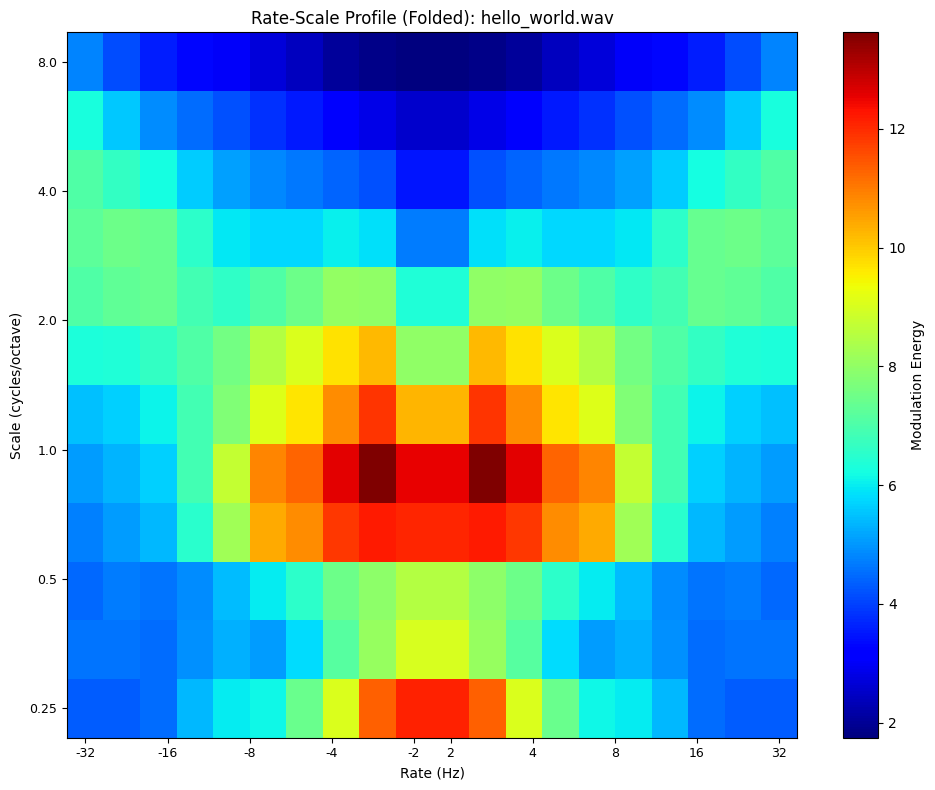

<Axes: title={'center': 'Rate-Scale Profile (Folded): hello_world.wav'}, xlabel='Rate (Hz)', ylabel='Scale (cycles/octave)'>

In [7]:
# Plot RSF - folded (symmetric)
stm.plot.plt_rsf(rsf, fold=True, title=f"Rate-Scale Profile (Folded): {filepath.name}")

In [8]:
# Access rate-scale matrix directly
rs_matrix = rsf.rate_scale_matrix(fold=False)
rs_folded = rsf.rate_scale_matrix(fold=True)
print(f"Rate-scale matrix shape: {rs_matrix.shape}")
print(f"Folded matrix shape: {rs_folded.shape}")

Rate-scale matrix shape: (12, 20)
Folded matrix shape: (12, 20)
